# Generating a gyrotropic zero mean flow tri-maxwellian distribution

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import os
import h5py
import fipcore as fpc
import pyspedas
from pyspedas.projects import mms

In [54]:
trange = ['2015-12-09/05:03:55', '2015-12-09/05:03:59']

In [55]:
species = 'e'
bin_width_frac = 0.25
data_dir = os.path.join("..", "data")
subtract_f0 = False
type_tag = 'df' if subtract_f0 else 'f'
hfile_pref = f'fpc_mrx_{type_tag}_{species}_{bin_width_frac:.2f}'
hfile = os.path.join(data_dir, fpc.mms_name_make(hfile_pref, trange[0], trange[1]))

In [56]:
hfile

'../data/fpc_mrx_f_e_0.25_20151209_050355_050359.h5'

In [57]:
with h5py.File(hfile, "r") as f:
    ntime = f["meta"]["time"][:]
    vv_fac = f["fac"]["vv"][:]
    vvol = f["meta"]["vvol"][:]
    vdf_vol = f["gse"]["vdf_vol"][:]
    vdf_raw = f["gse"]["vdf_raw"][:]

In [58]:
import numpy as np
from scipy.constants import c, physical_constants
from pyspedas import get_data, tplot_rename
from pyspedas.projects import mms

def equilibrium_vdf(vv_fac, trange, species='e', probe='1', data_rate='brst', 
            level='l2', get_support_data=True, no_update=False, v_flow=None):
    fpi_vars = mms.fpi(trange=trange, probe=probe, data_rate=data_rate, level=level,
        datatype=[f'd{species}s-moms'], time_clip=True, 
        varnames=[f'mms1_d{species}s_temppara_brst', f'mms1_d{species}s_tempperp_brst', 
        f'mms1_d{species}s_numberdensity_brst'], get_support_data=get_support_data, 
        no_update=no_update)

    tplot_rename(f'mms1_d{species}s_temppara_brst', 't_para')
    tplot_rename(f'mms1_d{species}s_tempperp_brst', 't_perp')
    tplot_rename(f'mms1_d{species}s_numberdensity_brst', 'den')

    # Extract arrays from tplot
    _, den = get_data('den')    # Shape: (ntime,)
    _, t_para = get_data('t_para')    # Shape: (ntime,)
    _, t_perp = get_data('t_perp')    # Shape: (ntime,)

        # Mass constants in MeV converted to eV
    if species.lower() == 'ion':
        mc2_ev = physical_constants['proton mass energy equivalent in MeV'][0] * 1e6
    elif species.lower() == 'e':
        mc2_ev = physical_constants['electron mass energy equivalent in MeV'][0] * 1e6
    else:
        raise ValueError("Species must be 'ion' or 'e'")

    c_m_s = c   # Speed of light in m/s
    den_si = den * 1e6 # Convert density to m^-3
    
    # Calculate separate parallel and perpendicular thermal velocities (km/s)
    w_para = c_m_s * np.sqrt(2.0 * t_para / mc2_ev)  # Shape: (ntime,)
    w_perp = c_m_s * np.sqrt(2.0 * t_perp / mc2_ev)  # Shape: (ntime,)

    # Extract velocity components from the vv_fac(3, 16384, ntime) 
    v_x = vv_fac[0, :, :]*1e3  # Shape: (16384, ntime)
    v_y = vv_fac[1, :, :]*1e3  # Shape: (16384, ntime)
    v_z = vv_fac[2, :, :]*1e3  # Shape: (16384, ntime)

    # Expects v_flow as a 1D array/list of shape (3,) or a 2D array of shape (3, ntime)
    if v_flow is not None:
        v_x = v_x - v_flow[0]
        v_y = v_y - v_flow[1]
        v_z = v_z - v_flow[2]

    v_perp_sq = v_x**2 + v_y**2  # Shape: (16384, ntime)
    v_para_sq = v_z**2           # Shape: (16384, ntime)

    # Setting up Tri-Maxwellian
    amplitude = den_si / ((np.pi**1.5) * (w_perp**2) * w_para) # Shape: (ntime,)
    exponent = -(v_perp_sq / (w_perp**2)) - (v_para_sq / (w_para**2))
    vdf_eq = amplitude * np.exp(exponent)
    
    return vdf_eq

In [59]:
vdf_eq = equilibrium_vdf(vv_fac, trange)

12-Jun-26 14:22:05: Loading files for group: probe: 1, drate: brst, level: l2, datatype: des-moms, after sorting and filtering:
12-Jun-26 14:22:05: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/des-moms/2015/12/09/mms1_fpi_brst_l2_des-moms_20151209050044_v3.3.0.cdf
12-Jun-26 14:22:05: The name mms1_des_errorflags_brst is currently not in pyspedas
12-Jun-26 14:22:05: The name mms1_des_compressionloss_brst is currently not in pyspedas
12-Jun-26 14:22:05: The name mms1_des_pitchangdist_lowen_brst is currently not in pyspedas
12-Jun-26 14:22:05: The name mms1_des_pitchangdist_miden_brst is currently not in pyspedas
12-Jun-26 14:22:05: The name mms1_des_pitchangdist_highen_brst is currently not in pyspedas
12-Jun-26 14:22:05: The name mms1_des_errorflags_brst_moms is currently not in pyspedas
12-Jun-26 14:22:05: The name mms1_des_errorflags_brst_moms is currently not in pyspedas
12-Jun-26 14:22:05: The name mms1_des_compressionloss_brst_moms is currently not in pyspedas
12-Jun-26 14:22:05

In [60]:
vdf_eq_vol = vvol*vdf_eq

In [61]:
ne_eq = np.nansum(vdf_eq_vol, axis=0)   # (133,) units m^-3

In [62]:
den = mms.fpi(trange=trange, probe=1, data_rate='brst', level='l2', 
                            datatype=['des-moms'], time_clip=True,
                            varnames=['mms1_des_numberdensity_brst'], no_update=True)

12-Jun-26 14:22:06: Searching for local files...
12-Jun-26 14:22:06: Loading: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/des-moms/2015/12/09/mms1_fpi_brst_l2_des-moms_20151209050044_v3.3.0.cdf
12-Jun-26 14:22:06: Loading files for group: probe: 1, drate: brst, level: l2, datatype: des-moms, after sorting and filtering:
12-Jun-26 14:22:06: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/des-moms/2015/12/09/mms1_fpi_brst_l2_des-moms_20151209050044_v3.3.0.cdf
12-Jun-26 14:22:06: The name mms1_des_errorflags_brst is currently not in pyspedas
12-Jun-26 14:22:06: The name mms1_des_compressionloss_brst is currently not in pyspedas
12-Jun-26 14:22:06: The name mms1_des_pitchangdist_lowen_brst is currently not in pyspedas
12-Jun-26 14:22:06: The name mms1_des_pitchangdist_miden_brst is currently not in pyspedas
12-Jun-26 14:22:06: The name mms1_des_pitchangdist_highen_brst is currently not in pyspedas
12-Jun-26 14:22:06: The name mms1_des_errorflags_brst_moms is currently not in pyspedas
1

In [63]:
pyspedas.tplot_rename('mms1_des_numberdensity_brst', 'ne_mms1')

In [64]:
_, ne_mms1 = get_data('ne_mms1')

In [65]:
d_vdf_vol = vdf_vol - vdf_eq_vol

In [66]:
ne_vdf = np.nansum(vdf_vol, axis=0)   # (133,) units m^-3
ne_dvdf = np.nansum(d_vdf_vol, axis=0)   # (133,) units m^-3

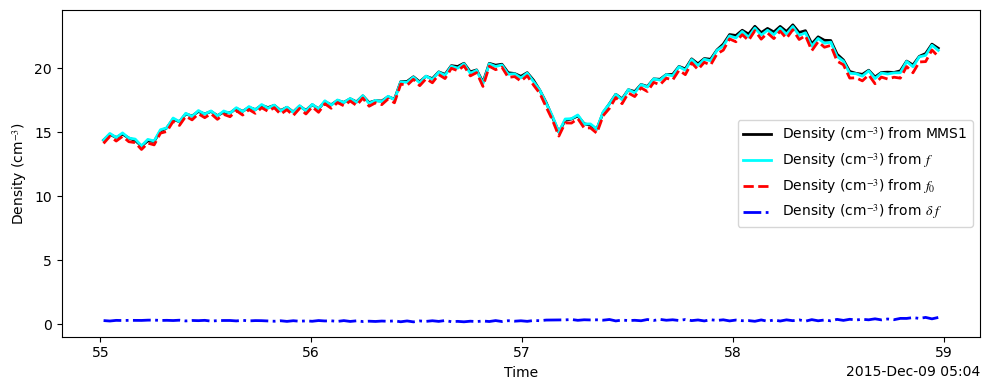

In [67]:
import matplotlib.pyplot as plt
from pyspedas import time_datetime

# Convert your density from m^-3 → cm^-3
ne_vdf_cm = ne_vdf * 1e-6
ne_eq_cm = ne_eq * 1e-6
ne_dvdf_cm = ne_dvdf * 1e-6
time_dt = time_datetime(ntime)
plt.figure(figsize=(10,4))

plt.plot(time_dt, ne_mms1, label='Density (cm$^{-3}$) from MMS1', color='k', linewidth=2)
plt.plot(time_dt, ne_vdf_cm, label='Density (cm$^{-3}$) from $f$', color='cyan', linewidth=2)
plt.plot(time_dt, ne_eq_cm, '--', label='Density (cm$^{-3}$) from $f_0$', color='r', linewidth=2)
plt.plot(time_dt, ne_dvdf_cm, '-.', label=r'Density (cm$^{-3}$) from $\delta~f$', color='b', linewidth=2)

plt.xlabel('Time')
plt.ylabel('Density (cm$^{-3}$)')
plt.legend()
plt.tight_layout()
plt.show()

# Doing the same tests with the save file

In [68]:
type_tag = 'df'
hfile_pref = f'fpc_mrx_{type_tag}_{species}_{bin_width_frac:.2f}'
hfile1 = os.path.join(data_dir, fpc.mms_name_make(hfile_pref, trange[0], trange[1]))

In [69]:
hfile, hfile1

('../data/fpc_mrx_f_e_0.25_20151209_050355_050359.h5',
 '../data/fpc_mrx_df_e_0.25_20151209_050355_050359.h5')

In [70]:
with h5py.File(hfile1, "r") as f:
        time1 = f["meta"]["time"][:]
        vdf_vol1 = f["meta"]["vdf_vol"][:]
        vdf_eq1 = f["fac"]["vdf_eq"][:]
        vvol1 = f["meta"]["vvol"][:]

## 0th order moment or number density

In [71]:
vdf_eq_vol1 = vdf_eq1*vvol1 # from f_0

In [72]:
ne_eq1 = np.nansum(vdf_eq_vol1, axis=0)   # from f_0
ne_dvdf1 = np.nansum(vdf_vol1, axis=0)   # from df

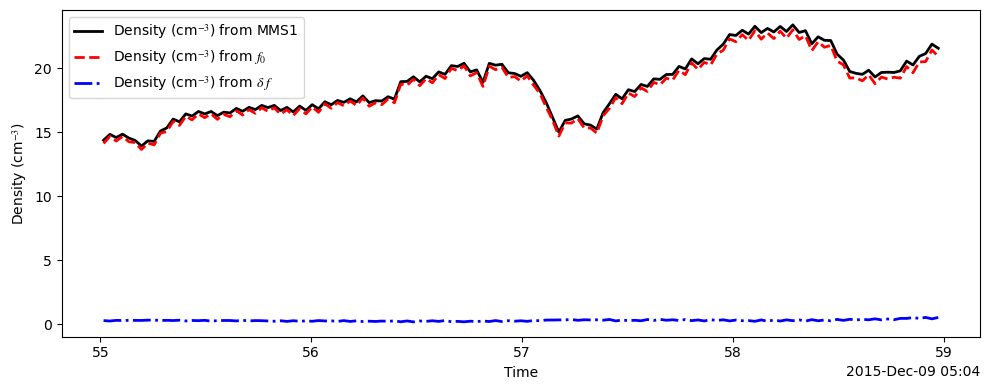

In [73]:
import matplotlib.pyplot as plt
from pyspedas import time_datetime

# Convert your density from m^-3 → cm^-3
ne_eq_cm1 = ne_eq1 * 1e-6
ne_dvdf_cm1 = ne_dvdf1 * 1e-6
time_dt = time_datetime(ntime)
plt.figure(figsize=(10,4))

plt.plot(time_dt, ne_mms1, label='Density (cm$^{-3}$) from MMS1', color='k', linewidth=2)
plt.plot(time_dt, ne_eq_cm1, '--', label='Density (cm$^{-3}$) from $f_0$', color='r', linewidth=2)
plt.plot(time_dt, ne_dvdf_cm1, '-.', label=r'Density (cm$^{-3}$) from $\delta~f$', color='b', linewidth=2)

plt.xlabel('Time')
plt.ylabel('Density (cm$^{-3}$)')
plt.legend()
plt.tight_layout()
plt.show()

In [74]:
np.array_equal(ne_eq, ne_eq1)

True

## 1st order moment or mean flow

In [75]:
with h5py.File(hfile1, "r") as f:
        time = f["meta"]["time"][:]
        vv_fac = f["fac"]["vv"][:] # in km/s
        vdf_raw = f["meta"]["vdf_raw"][:] # in si units without vvol weighting
        vdf_eq = f["fac"]["vdf_eq"][:]  # in si units without vvol weighting
        df_vol = f["meta"]["vdf_vol"][:] # in m^-3
        vvol = f["meta"]["vvol"][:] # (m/s)^3

In [76]:
vdf_vol = vdf_raw*vvol

In [77]:
vdf_eq_vol = vdf_eq*vvol

In [78]:
vdf_vol.shape, vdf_eq_vol.shape

((16384, 133), (16384, 133))

In [79]:
ne_eqf = np.nansum(vdf_eq_vol, axis=0)   # density from f_0

So no mistake in computation of densities

In [80]:
vv_fac.shape, vdf_eq_vol.shape

((3, 16384, 133), (16384, 133))

In [81]:
v_num_f = np.nansum(vv_fac*vdf_vol, axis=1) # mean flow from f
bulk_ve_f = (v_num_f/ne_eqf).T

In [82]:
v_num_df = np.nansum(vv_fac*df_vol, axis=1)
bulk_ve_df = (v_num_df/ne_eqf).T

In [83]:
bulkve = mms.fpi(trange= trange, probe='1', data_rate='brst',level='l2',
        datatype=['des-dist', 'des-moms'], time_clip=True, 
        varnames=['mms1_des_bulkv_gse_brst'], get_support_data=True, no_update=True)

12-Jun-26 14:22:11: Searching for local files...
12-Jun-26 14:22:11: Loading: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/des-dist/2015/12/09/mms1_fpi_brst_l2_des-dist_20151209050044_v3.3.0.cdf
12-Jun-26 14:22:11: Searching for local files...
12-Jun-26 14:22:11: Loading: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/des-moms/2015/12/09/mms1_fpi_brst_l2_des-moms_20151209050044_v3.3.0.cdf
12-Jun-26 14:22:11: Loading files for group: probe: 1, drate: brst, level: l2, datatype: des-dist, after sorting and filtering:
12-Jun-26 14:22:11: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/des-dist/2015/12/09/mms1_fpi_brst_l2_des-dist_20151209050044_v3.3.0.cdf
12-Jun-26 14:22:11: Loading files for group: probe: 1, drate: brst, level: l2, datatype: des-moms, after sorting and filtering:
12-Jun-26 14:22:11: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/des-moms/2015/12/09/mms1_fpi_brst_l2_des-moms_20151209050044_v3.3.0.cdf
12-Jun-26 14:22:11: wildcard_expand: No match found for *_des_errorf

In [84]:
tplot_rename('mms1_des_bulkv_gse_brst', 'bulk_ve_mms')

In [85]:
_, bulk_ve_mms = get_data('bulk_ve_mms')

In [86]:
bulk_ve_mms.shape

(133, 3)

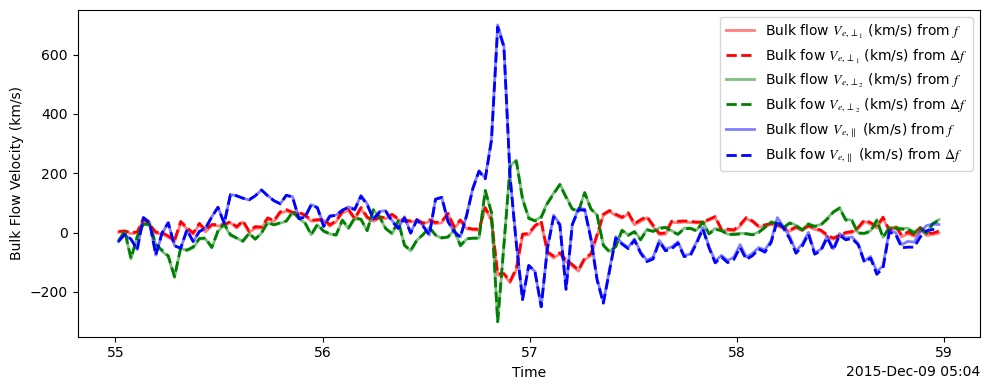

In [87]:
import matplotlib.pyplot as plt
from pyspedas import time_datetime

time_dt = time_datetime(time)
plt.figure(figsize=(10,4))

labels = [r'$V_{e,\perp_1}$', r'$V_{e,\perp_2}$', r'$V_{e,\parallel}$']
colors = ['r','g','b']

for i, c in enumerate(colors):
    # bulk flow from mms1
    plt.plot(time_dt, bulk_ve_f[:, i], color = c, 
        label=f'Bulk flow {labels[i]} (km/s) from $f$',linewidth=2, alpha=0.5)
    # bulk flow from delta_f
    plt.plot(time_dt, bulk_ve_df[:, i], '--', color = c, 
        label=fr'Bulk fow {labels[i]} (km/s) from $\Delta f$',linewidth=2)
    # bulk flow from full f
    # plt.plot(time_dt, bulk_ve_f[:, i], '--', color = c, 
    #     label=f'VDF {labels[i]} (km/s)', linewidth=2)

plt.xlabel('Time')
plt.ylabel('Bulk Flow Velocity (km/s)')
plt.legend()
plt.tight_layout()
plt.show()


# Checking J.E between f and delta_f

In [208]:
fgm_vars = mms.fgm(trange=trange, probe='1', data_rate='brst',
                            varformat='mms1_fgm_b_gse_brst_l2', time_clip=True, 
                            no_update=True)

12-Jun-26 15:30:30: Searching for local files...
12-Jun-26 15:30:30: Loading: /Users/rejohn/Data_Speedas/mms/mms1/fgm/brst/l2/2015/12/09/mms1_fgm_brst_l2_20151209050044_v4.22.0.cdf
12-Jun-26 15:30:30: Loading files for group: probe: 1, drate: brst, level: l2, datatype: , after sorting and filtering:
12-Jun-26 15:30:30: /Users/rejohn/Data_Speedas/mms/mms1/fgm/brst/l2/2015/12/09/mms1_fgm_brst_l2_20151209050044_v4.22.0.cdf


In [209]:
dat = mms.fpi(trange=trange, probe='1', data_rate='brst', level='l2', 
                            datatype=['des-moms', 'dis-moms'], time_clip=True,
                            varnames=['mms1_des_numberdensity_brst',
                                       'mms1_dis_bulkv_gse_brst',
                                       'mms1_des_bulkv_gse_brst'], no_update=True)

12-Jun-26 15:30:30: Searching for local files...
12-Jun-26 15:30:30: Loading: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/des-moms/2015/12/09/mms1_fpi_brst_l2_des-moms_20151209050044_v3.3.0.cdf
12-Jun-26 15:30:30: Searching for local files...
12-Jun-26 15:30:30: Loading: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/dis-moms/2015/12/09/mms1_fpi_brst_l2_dis-moms_20151209050044_v3.3.0.cdf
12-Jun-26 15:30:30: Loading files for group: probe: 1, drate: brst, level: l2, datatype: des-moms, after sorting and filtering:
12-Jun-26 15:30:30: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/des-moms/2015/12/09/mms1_fpi_brst_l2_des-moms_20151209050044_v3.3.0.cdf
12-Jun-26 15:30:30: Loading files for group: probe: 1, drate: brst, level: l2, datatype: dis-moms, after sorting and filtering:
12-Jun-26 15:30:30: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/dis-moms/2015/12/09/mms1_fpi_brst_l2_dis-moms_20151209050044_v3.3.0.cdf
12-Jun-26 15:30:30: The name mms1_des_errorflags_brst is currently n

In [210]:
pyspedas.tplot_rename('mms1_fgm_b_gse_brst_l2_bvec', 'bvec_gse')
pyspedas.tplot_rename('mms1_des_bulkv_gse_brst', 'bulk_ve_gse')
pyspedas.tplot_rename('mms1_dis_bulkv_gse_brst', 'bulk_vi_gse')

In [211]:
fpc.downsample_cad('bvec_gse', 'bulkve_gse', trange, newname='bvec_gse_d')

12-Jun-26 15:30:31: avg_data was applied to: bvec_gse_d


['bvec_gse_d']

In [212]:
pyspedas.fac_matrix_make(mag_var_name='bvec_gse_d', other_dim='Xgse', newname='fac_matrix')

'fac_matrix'

In [213]:
fpc.upsample_cad('bulk_vi_gse', 'bulk_ve_gse', newname='bulk_vi_gse_up')

12-Jun-26 15:30:34: tinterpol (linear) was applied to: bulk_vi_gse_up


'bulk_vi_gse_up'

In [216]:
fpc.rotate_to_fac?

Signature: fpc.rotate_to_fac(tplot_var, fac_mat_var)
Docstring:
Rotate a tplot variable using a given FAC matrix.

Parameters:
- tplot_var (str): Name of the tplot variable to be rotated.
- fac_mat_var (str): Name of the tplot variable containing the FAC matrix.

Returns:
- times (np.ndarray): Time array of the input data.
- tdata_rot (np.ndarray): Array of rotated data.
File:      ~/Library/CloudStorage/OneDrive-WestVirginiaUniversity/1 - Active Projects/MMS FPC/MMS FPC Analysis/FPC_mRx/fipcore/utils/coord_utils.py
Type:      function

In [217]:
times, bulk_vi_fac = fpc.rotate_to_fac('bulk_vi_gse_up', 'fac_matrix')

In [218]:
bulk_vi_fac.shape, bulk_ve_f.shape, bulk_ve_df.shape, ne_mms1.shape

((133, 3), (133, 3), (133, 3), (133,))

In [219]:
from scipy.constants import elementary_charge as q_e
jvec_df = ne_mms1[:, None] * q_e * (bulk_vi_fac - bulk_ve_df)*1e18 
# cm^-3 * C * km/s = 10^18 nA/m^2
jvec_f = ne_mms1[:, None] * q_e * (bulk_vi_fac - bulk_ve_f)*1e18 

In [220]:
edp_vars = mms.edp(trange=trange, probe='1', data_rate='brst',
            varnames=['mms1_edp_dce_gse_brst_l2', 'mms1_edp_dce_par_epar_brst_l2'],
            time_clip=True, no_update=True)

12-Jun-26 15:32:09: Searching for local files...
12-Jun-26 15:32:09: Loading: /Users/rejohn/Data_Speedas/mms/mms1/edp/brst/l2/dce/2015/12/09/mms1_edp_brst_l2_dce_20151209050044_v2.2.0.cdf
12-Jun-26 15:32:09: Loading files for group: probe: 1, drate: brst, level: l2, datatype: dce, after sorting and filtering:
12-Jun-26 15:32:09: /Users/rejohn/Data_Speedas/mms/mms1/edp/brst/l2/dce/2015/12/09/mms1_edp_brst_l2_dce_20151209050044_v2.2.0.cdf


In [221]:
pyspedas.tplot_rename('mms1_edp_dce_gse_brst_l2', 'evec_gse')

In [222]:
fpc.downsample_cad('evec_gse', 'bulk_ve_gse', trange, newname='evec_gse_d')

12-Jun-26 15:32:13: avg_data was applied to: evec_gse_d


['evec_gse_d']

In [248]:
idx = 60
bulk_vi_rev = fpc.vi_bl_flip(idx, 'bulk_vi_gse_up')

Bulk ion velocity at B_L reversal: [-136.93299866   54.14367294   13.21341801]


In [250]:
fpc.evec_to_recx('evec_gse_d', 'bvec_gse_d', bulk_vi_rev)

12-Jun-26 15:41:21: Setting coordinate system for evec_lor
12-Jun-26 15:41:21: Setting units for evec_lor


'evec_lor'

In [251]:
fpc.evec_to_fac('evec_lor', 'fac_matrix', newname='evec_lor_fac')

12-Jun-26 15:41:48: Setting coordinate system for evec_lor_fac
12-Jun-26 15:41:48: Setting units for evec_lor_fac


'evec_lor_fac'

In [252]:
_, evec_fac = pyspedas.get_data('evec_lor_fac')

In [261]:
times, jdotE, jdotE0, jdotE1, jdotE2 =  fpc.compute_jdotE(jvec_f, evec_fac)

In [262]:
times2, jdotE2, jdotE02, jdotE12, jdotE22 =  fpc.compute_jdotE(jvec_df, evec_fac)

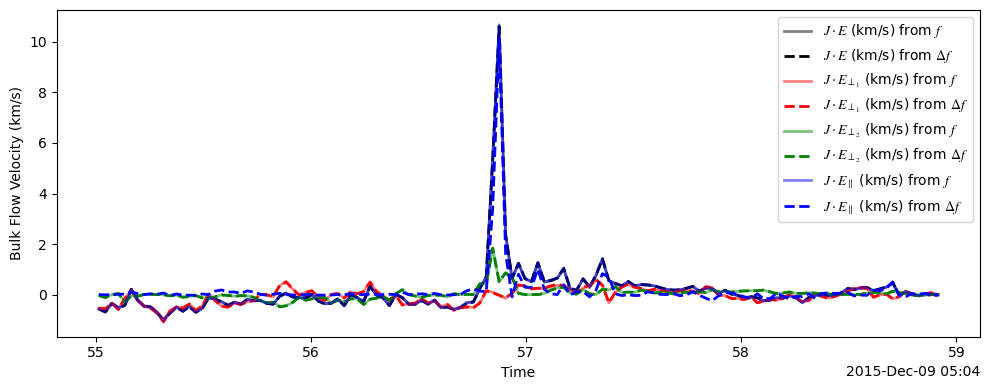

In [275]:
import matplotlib.pyplot as plt
from pyspedas import time_datetime

time_dt = time_datetime(time)
plt.figure(figsize=(10,4))

labels = [r'$J \cdot E$', r'$J \cdot E_{\perp_1}$', r'$J \cdot E_{\perp_2}$', 
    r'$J \cdot E_{\parallel}$']
colors = ['k','r','g','b']


# J.E from f
plt.plot(time_dt, jdotE, color = colors[0], 
    label=f'{labels[0]} (km/s) from $f$',linewidth=2, alpha=0.5)
# J.E from delta_f
plt.plot(time_dt, jdotE2, '--', color = colors[0], 
    label=fr'{labels[0]} (km/s) from $\Delta f$',linewidth=2)

# J.E perp1 from f
plt.plot(time_dt, jdotE0, color = colors[1], 
    label=f'{labels[1]} (km/s) from $f$',linewidth=2, alpha=0.5)
# J.E perp1 from delta_f
plt.plot(time_dt, jdotE02, '--', color = colors[1], 
    label=fr'{labels[1]} (km/s) from $\Delta f$',linewidth=2)

# J.E perp2 from f
plt.plot(time_dt, jdotE1, color = colors[2], 
    label=f'{labels[2]} (km/s) from $f$',linewidth=2, alpha=0.5)
# J.E perp2 from delta_f
plt.plot(time_dt, jdotE12, '--', color = colors[2], 
    label=fr'{labels[2]} (km/s) from $\Delta f$',linewidth=2)

# J.E para from f
plt.plot(time_dt, jdotE2, color = colors[3], 
    label=f'{labels[3]} (km/s) from $f$',linewidth=2, alpha=0.5)
# J.E para from delta_f
plt.plot(time_dt, jdotE22, '--', color = colors[3], 
    label=fr'{labels[3]} (km/s) from $\Delta f$',linewidth=2)

plt.xlabel('Time')
plt.ylabel('Bulk Flow Velocity (km/s)')
plt.legend()
plt.tight_layout()
plt.show()


# Generate FPC signatures on this delta f

from fipcore import imagecont_vdf_fpc

trange = ['2015-12-09/05:03:55', '2015-12-09/05:03:59']
t_list = [58, 59, 60, 61, 62, 63, 64]
for t_ind in t_list:
    imagecont_vdf_fpc(trange, species='e', bin_width_frac=0.25, time_index = t_ind,
            coord_type='both', suptitle_sfx='', dpi_val=100, axis_fntsz=16, 
            cbar_ht=0.050, save_fig=False, outdir_sfx='', show_tind=True)
    print(f'Files saved for time_index = {t_ind}')